In [63]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import os

In [66]:
data_directory = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week2/Fluo_stack/CTL9062"
save_path_max = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week2/Max_Fluo_img'
save_path_mean = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week2/Mean_Fluo_img'

In [67]:
# get a list of all tiff files
all_tiff_files = []
N = 0
for file in os.listdir(data_directory):
    if file.startswith("Test2_"):
        if file.endswith("cropped_stack.tif"):
            all_tiff_files.append(file)
            N+=1
    

all_names = [] 
for file in all_tiff_files: 
    all_names.append(file[:-4])
    
# properly sort the tiff files according to the time frame information    
all_names = sorted(all_names, key = lambda x: str(x[10:]))


all_sorted_tiff_files = [name+'.tif' for name in all_names]

all_sorted_directories = [ data_directory + "/" + file for file in all_sorted_tiff_files ]



for i in range(len(all_sorted_directories)):
    # Get the base name (filename without path and extension)
    Base_name = os.path.basename(all_sorted_directories[i])
    base_name, _ = os.path.splitext(Base_name[:-10])
    print(base_name)
    
    data = tifffile.TiffFile(all_sorted_directories[i])
    N = len(data.pages)
    m,n =data.pages[0].shape
    print(N,m,n)
    #Compute mean img
    mean_image = np.zeros([m,n])
    for frame in range(0,N-1):
        a_matrix =np.nan_to_num(data.pages[frame+1].asarray())
        mean_image = (frame*mean_image + a_matrix)/(frame+1)
    mean_image=mean_image.astype('float32')
    
    # Save the mean image with the base name
    output_path_mean = os.path.join(save_path_mean, f"{base_name}_mean.tif")
    tifffile.imwrite(output_path_mean, mean_image)
    
    #Compute max img
    sample_frame = 0
    min_value = np.min(np.nan_to_num(data.pages[sample_frame].asarray()).flatten())
    max_image = min_value*np.ones((m,n))
    for frame in range(0,N-1):
        a_matrix =np.nan_to_num(data.pages[frame].asarray())# tif.pages[frame].asarray()# 
        max_image = np.maximum(max_image,a_matrix)
    max_image=max_image.astype('float32')
    
    # Save the max image with the base name
    output_path_max = os.path.join(save_path_max, f"{base_name}_max.tif")
    tifffile.imwrite(output_path_max, max_image)



    

Test2_Week_2_2022_08_03_14_01_11_Fluo9001_CS1A1S1_cropped
840 880 880
Test2_Week_2_2022_08_05_11_47_47_Fluo9001_CS1A1S1_cropped
841 880 880
Test2_Week_2_2022_08_05_14_40_47_Fluo9001_CS3A1S1_cropped
840 880 880
Test2_Week_2_2022_08_05_17_03_14_Fluo9001_CS4A1S1_cropped
841 880 880


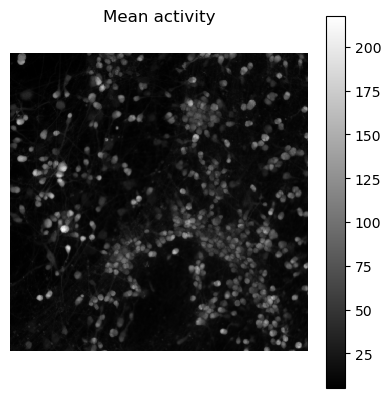

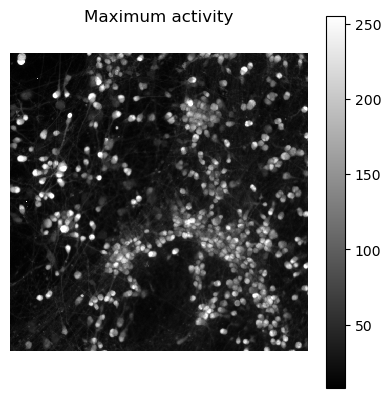

In [29]:
plt.matshow(mean_image)
plt.set_cmap('grey')
plt.colorbar()
plt.title('Mean activity')
plt.axis('off')
plt.show()

plt.matshow(max_image)

plt.set_cmap('grey')
plt.colorbar()
plt.title('Maximum activity')

plt.axis('off')
plt.show()